# HRV & Baevsky Stress Index Feature Extraction from ECG data

1. Loads a participant's combined ECG signal (and Kubios stress index for participants).
2. Slides a fixed-length window over continuous ECG segments.
3. Extracts NeuroKit2 HRV features and a Baevsky stress index per window.
4. Saves the per-window feature table and optionally validates it against Kubios.

In [1]:
import json
import os
import warnings
from typing import Optional

import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 5000)
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(suppress=True)


## Configuration

Tunable constants for the run. `WINDOW_SIZE_SEC` controls the analysis window length
(60 s in this variant). Set `PARTICIPANT_ID` and list UMN cohort ids in
`UMN_PARTICIPANTS` (participants with matching Kubios exports).

In [2]:
TIMEZONE: str = "US/Central"          # Local timezone for ECG timestamps
INPUT_DATA_FREQUENCY: int = 130        # ECG sampling rate in Hz
WINDOW_SIZE_SEC: int = 60              # Analysis window length in seconds
WINDOW_STEP_SEC: int = 50              # Step between consecutive windows in seconds
PARTICIPANT_ID: str = "FAKE01"               # Participant identifier 

# Root folder of the synthetic ecg data.
DATA_ROOT      = "../R21_data/synthetic_data_neuro"

# Participants collected at UMN have matching Kubios stress-index exports.
# (Ids are redacted in this backup; populate before running.)
UMN_PARTICIPANTS: list[str] = []
IS_UMN_PARTICIPANT: bool = PARTICIPANT_ID in UMN_PARTICIPANTS


## Data loading helpers

In [3]:
def load_json_dict(path: str) -> dict:
    """Load a JSON object from a text file.

    Returns:
        The parsed dictionary.
    """
    with open(path) as handle:
        return json.loads(handle.read())


def resolve_days_from_start(
    participant_id: str,
    is_umn: bool,
    data_root: str = DATA_ROOT,
) -> int:
    """Look up how many days into the study a participant's data should start.

    Args:
        participant_id: Participant identifier.
        is_umn: Whether the participant belongs to the UMN cohort.
        data_root: Root folder of the R21 data.

    Returns:
        The day offset (0 for non-UMN participants or when unset).
    """
    if not is_umn:
        return 0
    start_dict = load_json_dict(
        f"{data_root}/participant_info_folder/participant_start_dict.txt"
    )
    return int(start_dict.get(participant_id, 0) or 0)

In [4]:
def localize_timestamps(df: pd.DataFrame, timezone: str = TIMEZONE) -> pd.DataFrame:
    """Sort by timestamp and convert UTC timestamps to a local timezone.

    Args:
        df: DataFrame with a UTC ``timestamp`` column.
        timezone: Target timezone name.

    Returns:
        The DataFrame sorted and converted to local time.
    """
    df = df.sort_values("timestamp").reset_index(drop=True)
    df = df.set_index("timestamp")
    df = df.tz_localize("UTC").tz_convert(timezone)
    return df.sort_index().reset_index()


def load_ecg(
    participant_id: str,
    timezone: str = TIMEZONE,
    data_root: str = DATA_ROOT,
) -> pd.DataFrame:
    """Load a participant's combined ECG pickle as timezone-naive local time.

    Args:
        participant_id: Participant identifier.
        timezone: Target timezone name.
        data_root: Root folder of the R21 data tree.

    Returns:
        ECG DataFrame with a timezone-naive ``timestamp`` column.
    """
    ecg_df = pd.read_pickle(f"{data_root}/combined_picklefiles/{participant_id}_allecg.pkl")
    ecg_df = localize_timestamps(ecg_df, timezone)
    ecg_df["timestamp"] = ecg_df["timestamp"].dt.tz_localize(None)
    return ecg_df


def load_kubios_si(participant_id: str, data_root: str = DATA_ROOT) -> pd.DataFrame:
    """Load a participant's Kubios stress-index export."""
    
    si_kubio = pd.read_pickle(f"{data_root}/kubios_pkl_Fall2024/{participant_id}")
    return si_kubio.sort_values("timestamp")

In [5]:
def fast_filter_by_timestamp(
    df: pd.DataFrame,
    timestamp_list: list[pd.Timestamp],
    half_window_sec: int = 30,
) -> pd.DataFrame:
    """Keep only rows within +/- a window around each reference timestamp.

    Uses ``np.searchsorted`` for an efficient range lookup on a sorted frame.

    Args:
        df: DataFrame sorted by a ``timestamp`` column.
        timestamp_list: Reference timestamps to retain data around.
        half_window_sec: Half-width of the retention window, in seconds.

    Returns:
        Concatenated DataFrame of rows falling inside any window.
    """
    timestamp_series = pd.Series(timestamp_list)
    time_windows = pd.DataFrame(
        {
            "start_time": timestamp_series - pd.Timedelta(seconds=half_window_sec),
            "end_time": timestamp_series + pd.Timedelta(seconds=half_window_sec),
        }
    )

    start_indices = np.searchsorted(df["timestamp"], time_windows["start_time"])
    end_indices = np.searchsorted(df["timestamp"], time_windows["end_time"], side="right")

    slices = [df.iloc[start:end] for start, end in zip(start_indices, end_indices)]
    return pd.concat(slices)

## Feature extraction

Window the ECG into continuous segments and compute NeuroKit2 HRV features plus a
Baevsky stress index for each window.

In [6]:
def compute_baevsky_stress_index(
    ecg_segment: pd.Series | np.ndarray,
    sampling_rate: int,
) -> Optional[float]:
    """Compute the Baevsky stress index (SI) from an ECG segment.

    The SI is derived from NN-interval statistics as
    ``SI = AMo / (2 * Mo * MxDMn)``, where ``Mo`` is the mode of the NN intervals,
    ``AMo`` its amplitude (% within +/-50 ms of the mode) and ``MxDMn`` the
    variation range.

    Args:
        ecg_segment: Raw ECG samples for one window.
        sampling_rate: ECG sampling rate in Hz.

    Returns:
        The Baevsky stress index, or ``None`` if it cannot be computed.
    """
    ecg_cleaned = nk.ecg_clean(ecg_segment, sampling_rate=sampling_rate)
    r_peaks = nk.ecg_findpeaks(ecg_cleaned, sampling_rate=sampling_rate)["ECG_R_Peaks"]
    if len(r_peaks) <= 1:
        return None

    nn_intervals_ms = np.diff(r_peaks) / sampling_rate * 1000.0
    if len(nn_intervals_ms) == 0:
        return None

    mode_ms = float(np.round(np.median(nn_intervals_ms), 2))                      # Mo
    amo = (
        np.sum((nn_intervals_ms >= mode_ms - 50) & (nn_intervals_ms <= mode_ms + 50))
        / len(nn_intervals_ms)
        * 100
    )                                                                              # AMo (%)
    variation_range_ms = float(np.max(nn_intervals_ms) - np.min(nn_intervals_ms))  # MxDMn
    if variation_range_ms == 0:
        return None
    return amo / (2 * mode_ms * variation_range_ms)

In [7]:
def process_ecg_windows(
    df: pd.DataFrame,
    window_size_sec: int,
    window_step_sec: int,
    sampling_rate: int = INPUT_DATA_FREQUENCY,
) -> tuple[list[dict], list[dict]]:
    """Slide a window over continuous ECG segments and extract HRV and SI features.

    The frame is split into continuous segments (a gap greater than 0.1 s starts a
    new segment). Each full window is analyzed with NeuroKit2 to produce HRV
    features and a Baevsky stress index.

    Args:
        df: ECG DataFrame with ``timestamp`` and ``ecg`` columns.
        window_size_sec: Window length in seconds.
        window_step_sec: Step between windows in seconds.
        sampling_rate: ECG sampling rate in Hz.

    Returns:
        A tuple ``(windows, analysis_results)`` where ``windows`` holds the raw ECG
        per window and ``analysis_results`` holds per-window HRV dictionaries
        (each including its Baevsky stress index).
    """
    window_size = window_size_sec * sampling_rate
    window_step = window_step_sec * sampling_rate

    df = df.sort_values("timestamp").reset_index(drop=True)
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Start a new segment whenever the gap between samples exceeds 0.1 seconds.
    df["time_diff"] = df["timestamp"].diff().dt.total_seconds()
    df["segment"] = (df["time_diff"] > 0.1).cumsum()

    windows: list[dict] = []
    analysis_results: list[dict] = []

    for _, group in tqdm(df.groupby("segment"), desc="Processing segments"):
        if len(group) < window_size:
            continue

        num_windows = (len(group) - window_size) // window_step + 1
        for i in range(num_windows):
            start_idx = i * window_step
            window_data = group.iloc[start_idx : start_idx + window_size]
            if len(window_data) != window_size:
                continue

            start_timestamp = window_data["timestamp"].iloc[0]
            windows.append(
                {"start_timestamp": start_timestamp, "ecg_data": window_data["ecg"].tolist()}
            )

            try:
                ecg_signal = window_data["ecg"].tolist()
                peaks, _ = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)
                analysis = nk.hrv(peaks, sampling_rate=sampling_rate, show=False)
                stress_index = compute_baevsky_stress_index(window_data["ecg"], sampling_rate)

                analysis_results.append(
                    {
                        "start_timestamp": start_timestamp,
                        "analysis": analysis,
                        "stress_index": stress_index,
                    }
                )
            except Exception as error:  # keep going on per-window failures
                print(f"Error processing window at {start_timestamp}: {error}")
                analysis_results.append(
                    {
                        "start_timestamp": start_timestamp,
                        "analysis": None,
                        "stress_index": None,
                        "error": str(error),
                    }
                )

    return windows, analysis_results


In [8]:
def analysis_result_to_dataframe(analysis_results: list[dict]) -> pd.DataFrame:
    """Flatten per-window HRV analysis results into a single DataFrame.

    Args:
        analysis_results: List of per-window result dictionaries.

    Returns:
        Combined HRV DataFrame with ``timestamp`` and ``stress_index_neurokit``
        columns, or an empty DataFrame when there are no valid results.
    """
    frames: list[pd.DataFrame] = []
    for result in analysis_results:
        analysis = result.get("analysis")
        if analysis is None:
            continue
        frame = pd.DataFrame(analysis)
        frame["timestamp"] = result.get("start_timestamp")
        frame["stress_index_neurokit"] = result.get("stress_index")
        frames.append(frame)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

## Diagnostics & post-processing

Helpers to inspect data completeness and to normalize / resample the stress
index for downstream analysis.

In [9]:
def report_non_nan_percentage(df: pd.DataFrame) -> pd.Series:
    """Return the percentage of non-NaN values per column.

    Args:
        df: DataFrame to inspect.

    Returns:
        Series mapping each column to its non-NaN percentage.
    """
    return df.notna().mean() * 100


def check_dataframe_nan(df: pd.DataFrame) -> None:
    """Print NaN counts per column for a quick data-quality check."""

    nan_counts = df.isna().sum()
    columns_with_nan = nan_counts[nan_counts > 0]
    if columns_with_nan.empty:
        print("No NaN values found.")
    else:
        print("Columns with NaN values:")
        print(columns_with_nan)


def normalize_and_resample_stress(
    analysis_df: pd.DataFrame,
    rule: str = "1T",
) -> pd.DataFrame:
    """Normalize the stress index to 0-100 and resample to a fixed cadence.

    Args:
        analysis_df: DataFrame with ``timestamp`` and ``stress_index_neurokit``.
        rule: Pandas resampling rule (default one minute).

    Returns:
        DataFrame with ``timestamp`` and ``stress_index_normalized`` columns.
    """
    df = analysis_df.copy()
    min_value = df["stress_index_neurokit"].min()
    max_value = df["stress_index_neurokit"].max()
    value_range = max_value - min_value
    df["stress_index_normalized"] = (
        (df["stress_index_neurokit"] - min_value) / value_range * 100
        if value_range != 0
        else 0
    )

    df = df.set_index("timestamp")
    resampled = df[["stress_index_normalized"]].resample(rule).mean()
    return resampled.reset_index()

## Run pipeline

Load the participant's ECG, restrict to the relevant time windows, extract
features, run diagnostics and save the results.

In [10]:
# Load the participant ECG and (for UMN participants) the Kubios reference.
ecg_df = load_ecg(PARTICIPANT_ID)
si_kubio = load_kubios_si(PARTICIPANT_ID) if IS_UMN_PARTICIPANT else None

if IS_UMN_PARTICIPANT and si_kubio is not None:
    # Keep only ECG around the Kubios reference timestamps to reduce volume.
    time_to_keep = si_kubio["timestamp"].tolist()
    filtered_ecg_df = fast_filter_by_timestamp(ecg_df, time_to_keep)
else:
    filtered_ecg_df = ecg_df

filtered_ecg_df = (
    filtered_ecg_df.drop_duplicates(subset="timestamp")
    .sort_values("timestamp")
    .reset_index(drop=True)
)
print(f"Filtered ECG rows: {len(filtered_ecg_df)}")

Filtered ECG rows: 936000


In [11]:
filtered_ecg_df.head()

,timestamp,ecg
0,2024-10-01 09:00:00.000000000,0.00
1,2024-10-01 09:00:00.007692307,-0.01
2,2024-10-01 09:00:00.015384614,-0.01
3,2024-10-01 09:00:00.023076921,0.01
4,2024-10-01 09:00:00.030769228,0.00


In [12]:
windows, analysis_results = process_ecg_windows(
    filtered_ecg_df,
    WINDOW_SIZE_SEC,
    WINDOW_STEP_SEC,
    INPUT_DATA_FREQUENCY,
)

print(f"Number of windows: {len(windows)}")
print(f"Approx. hours of data: {len(windows) * WINDOW_STEP_SEC / 3600:.2f}")


Processing segments: 100%|██████████| 12/12 [00:06<00:00,  1.97it/s]

Number of windows: 132
Approx. hours of data: 1.83


In [13]:
# Flatten per-window HRV results and run data-quality diagnostics.
analysis_df = analysis_result_to_dataframe(analysis_results)

print("Non-NaN percentage per column:")
print(report_non_nan_percentage(analysis_df))
check_dataframe_nan(analysis_df)

Non-NaN percentage per column:
HRV_MeanNN                     100.00
HRV_SDNN                       100.00
HRV_SDANN1                       0.00
HRV_SDNNI1                       0.00
HRV_SDANN2                       0.00
HRV_SDNNI2                       0.00
HRV_SDANN5                       0.00
HRV_SDNNI5                       0.00
HRV_RMSSD                      100.00
HRV_SDSD                       100.00
HRV_CVNN                       100.00
HRV_CVSD                       100.00
HRV_MedianNN                   100.00
HRV_MadNN                      100.00
HRV_MCVNN                      100.00
HRV_IQRNN                      100.00
HRV_SDRMSSD                    100.00
HRV_Prc20NN                    100.00
HRV_Prc80NN                    100.00
HRV_pNN50                      100.00
HRV_pNN20                      100.00
HRV_MinNN                      100.00
HRV_MaxNN                      100.00
HRV_HTI                        100.00
HRV_TINN                       100.00
HRV_ULF            

In [14]:
# Persist the per-window HRV + stress-index analysis to a pickle.
output_dir = f"{DATA_ROOT}/ecg_neurokit/{PARTICIPANT_ID}/"
os.makedirs(output_dir, exist_ok=True)

output_path = f"{output_dir}neurokit2_ecg_analysis_{WINDOW_SIZE_SEC}sec_{PARTICIPANT_ID}.pkl"
# analysis_df.to_pickle(output_path)
# print(f"Saved analysis to: {output_path}")


In [15]:
analysis_df.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV,timestamp,stress_index_neurokit
0,897.51,30.92,NaN,NaN,NaN,NaN,NaN,NaN,45.24,45.60,...,1.73,2.02,4.73,1.48,0.06,0.44,0.08,0.41,2024-10-01 09:00:00.000000000,0.00
1,889.28,29.71,NaN,NaN,NaN,NaN,NaN,NaN,42.18,42.50,...,1.52,2.01,6.07,1.28,0.06,0.19,0.16,0.59,2024-10-01 09:00:49.999995500,0.00
2,893.24,39.03,NaN,NaN,NaN,NaN,NaN,NaN,48.32,48.70,...,2.10,1.96,3.52,1.19,0.09,0.44,0.11,0.36,2024-10-01 09:01:39.999991000,0.00
3,896.57,36.54,NaN,NaN,NaN,NaN,NaN,NaN,47.63,48.01,...,1.79,2.00,4.27,1.20,0.08,0.46,0.13,0.33,2024-10-01 09:02:29.999986500,0.00
4,895.27,41.82,NaN,NaN,NaN,NaN,NaN,NaN,56.54,56.99,...,2.50,1.99,4.56,1.11,0.00,0.46,0.13,0.41,2024-10-01 09:03:19.999982000,0.00


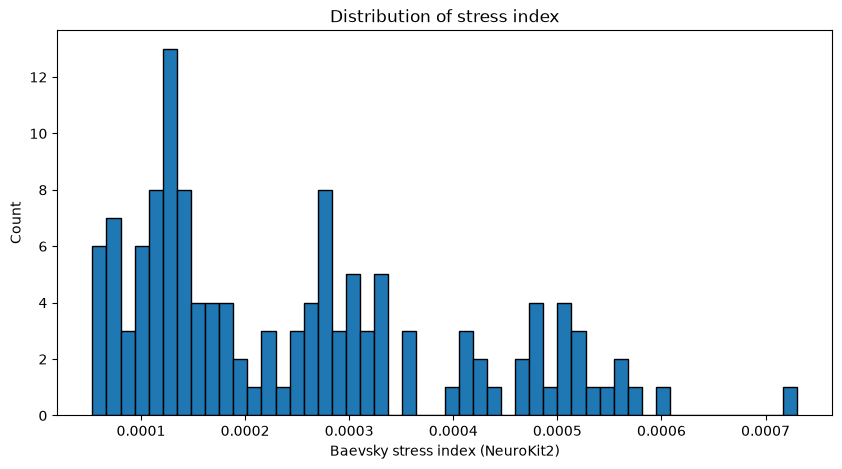

90th percentile of stress index: 0.0005


In [16]:
# Visualize the stress-index distribution and report its 90th percentile.
import os

os.makedirs("../outputs", exist_ok=True)
plt.figure(figsize=(10, 5))
plt.hist(analysis_df["stress_index_neurokit"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Baevsky stress index (NeuroKit2)")
plt.ylabel("Count")
plt.title("Distribution of stress index")
plt.savefig("../outputs/example_plot.png", dpi=150, bbox_inches="tight")
plt.show()

percentile_90 = analysis_df["stress_index_neurokit"].quantile(0.90)
print(f"90th percentile of stress index: {percentile_90:.4f}")


## Validate against Kubios

For UMN participants, compare the NeuroKit2-derived stress index and heart rate
against the Kubios reference values.

In [17]:
# Correlate the normalized NeuroKit2 stress index against the Kubios SI.
if IS_UMN_PARTICIPANT and si_kubio is not None:
    neurokit_resampled = normalize_and_resample_stress(analysis_df, rule="1T")

    kubios_resampled = (
        si_kubio.set_index("timestamp")[["SI"]].resample("1T").mean().reset_index()
    )

    merged_si = pd.merge(neurokit_resampled, kubios_resampled, on="timestamp", how="inner")
    merged_si = merged_si.dropna(subset=["stress_index_normalized", "SI"])

    si_correlation = merged_si["stress_index_normalized"].corr(merged_si["SI"]) * 100
    print(f"Stress-index correlation with Kubios: {si_correlation:.2f}%")
else:
    print("Kubios stress-index validation skipped (not a UMN participant).")

Kubios stress-index validation skipped (not a UMN participant).


In [18]:
# Correlate NeuroKit2 mean NN interval against the Kubios mean RR interval.
if IS_UMN_PARTICIPANT and si_kubio is not None:
    kubio_hr = (
        si_kubio.dropna()[["timestamp", "mean_RR"]]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )
    kubio_hr["timestamp"] = pd.to_datetime(kubio_hr["timestamp"])

    merged_hr = pd.merge_asof(
        kubio_hr,
        analysis_df[["timestamp", "HRV_MeanNN"]].sort_values("timestamp"),
        on="timestamp",
        direction="nearest",
        tolerance=pd.Timedelta(seconds=50),
    )

    merged_hr["HRV_MeanNN"] = pd.to_numeric(merged_hr["HRV_MeanNN"], errors="coerce")
    merged_hr["mean_RR"] = pd.to_numeric(merged_hr["mean_RR"], errors="coerce")
    merged_hr = merged_hr.dropna(subset=["HRV_MeanNN", "mean_RR"])

    hr_correlation = merged_hr["HRV_MeanNN"].corr(merged_hr["mean_RR"])
    print(f"Mean-NN correlation with Kubios mean RR: {hr_correlation:.4f}")
else:
    print("Kubios heart-rate validation skipped (not a UMN participant).")

Kubios heart-rate validation skipped (not a UMN participant).
